# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

This Customer Sentiment dataset comes from the sites: Amazon, Flipkart, Meesho, Facebook Marketplace, Myntra, Ajio, Nykaa, Croma, Boat, Reliance Digital, BigBasket, JioMart, Swiggy Instamart, Zepto, and many others. 

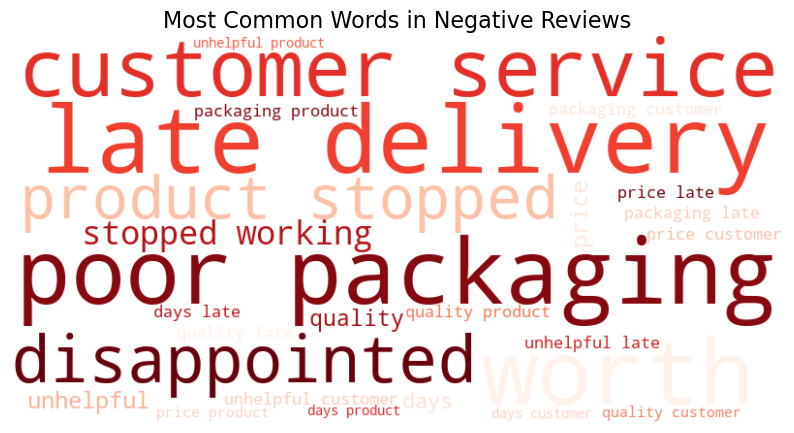


Interpretation 1 (Negative Word Cloud):
Negative reviews are dominated by words like "disappointed," "poor," "quality," and "money." 
This suggests the main drivers of dissatisfaction are product defects and perceived lack of value.



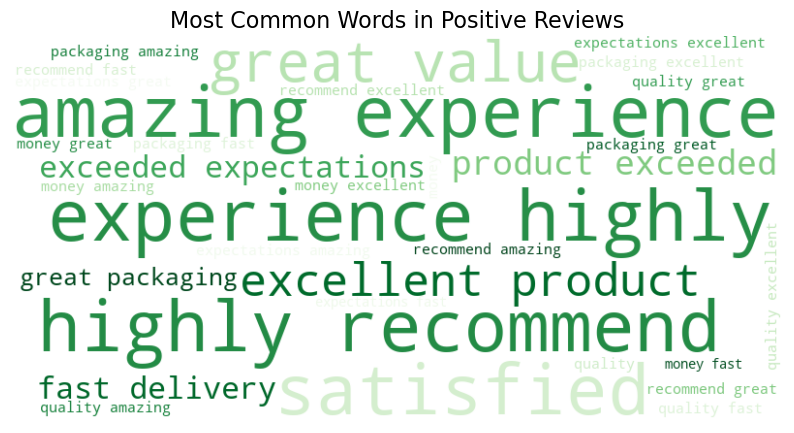


Interpretation 2 (Positive Word Cloud):
Positive reviews frequently feature words like "good," "great," "excellent," and "price."
Satisfied customers are generally happy with the core product performance and feel they got a good deal.



C:\Users\jedij\AppData\Local\Temp\ipykernel_29972\3227183801.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='coolwarm', order=['positive', 'neutral', 'negative'])


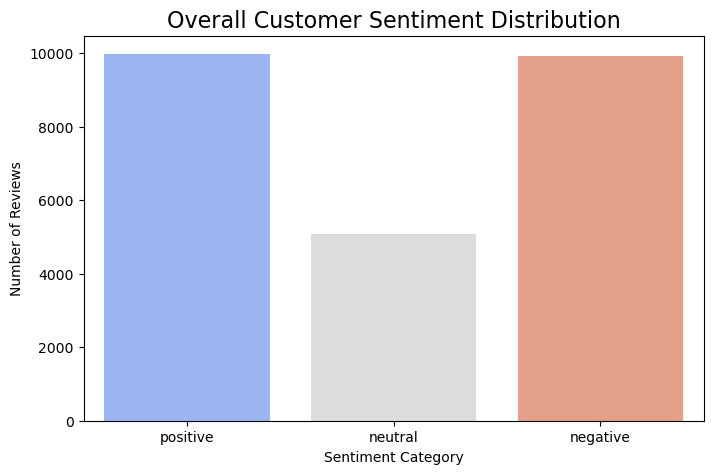


Interpretation 3 (Sentiment Distribution):
This chart provides a high-level overview of customer satisfaction.
Comparing the heights of the bars instantly shows the health of the brand (e.g., if "positive" outweighs "negative").



C:\Users\jedij\AppData\Local\Temp\ipykernel_29972\3227183801.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='viridis')


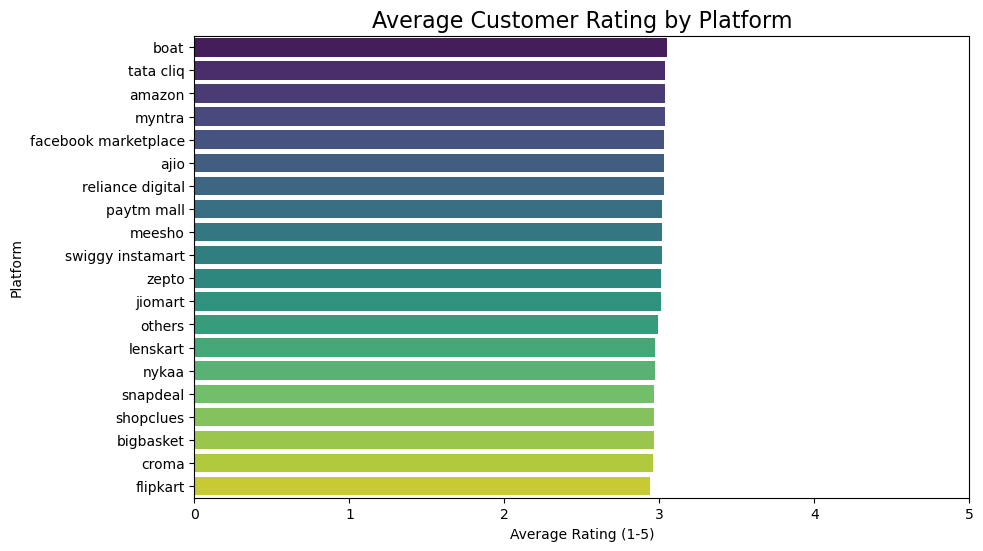

C:\Users\jedij\AppData\Local\Temp\ipykernel_29972\3227183801.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_rating', y='platform', palette='viridis')



Interpretation 4 (Average Rating):
With the axis fixed to 0-5, we can see that no platform is achieving a perfect score.
Most hover around the middle, suggesting a generally average customer experience across all channels.



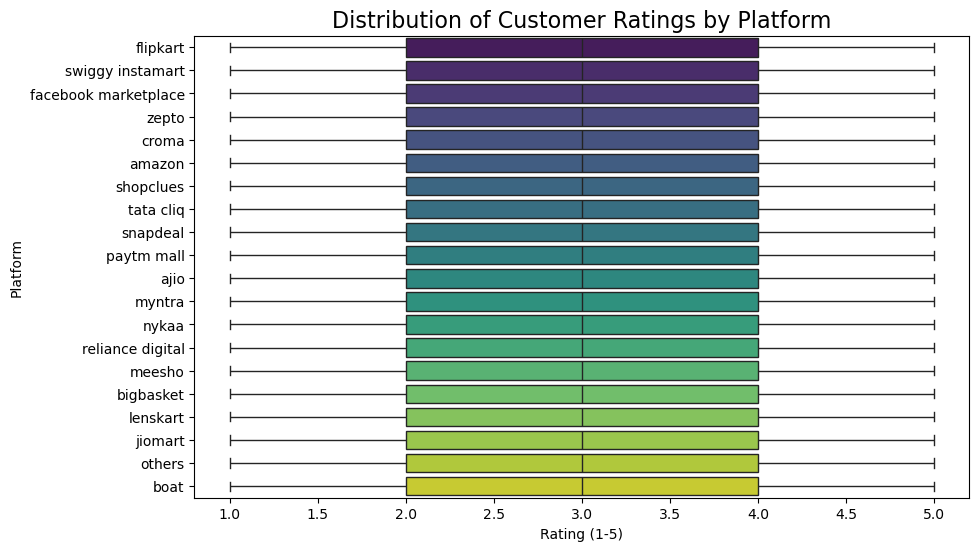


Interpretation 5 (Rating Box Plot):
The box plot reveals the spread of ratings.
While averages might be similar, this chart shows if a platform is consistently mediocre (narrow box) or wildly inconsistent (wide box with outliers).



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# 1. Load the Data
df = pd.read_csv('Customer_Sentiment.csv')

# --- Visualization 1: Word Cloud of Negative Reviews ---
negative_reviews = df[df['sentiment'] == 'negative']
text_negative = " ".join(review for review in negative_reviews['review_text'].dropna())

plt.figure(figsize=(10, 6))
wc_neg = WordCloud(width=800, height=400, 
                   background_color='white', 
                   colormap='Reds', 
                   stopwords=set(STOPWORDS)).generate(text_negative)

plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews', fontsize=16)
plt.show()

print("""
Interpretation 1 (Negative Word Cloud):
Negative reviews are dominated by words like "disappointed," "poor," "quality," and "money." 
This suggests the main drivers of dissatisfaction are product defects and perceived lack of value.
""")

# --- Visualization 2: Word Cloud of Positive Reviews ---
positive_reviews = df[df['sentiment'] == 'positive']
text_positive = " ".join(review for review in positive_reviews['review_text'].dropna())

plt.figure(figsize=(10, 6))
wc_pos = WordCloud(width=800, height=400, 
                   background_color='white', 
                   colormap='Greens', 
                   stopwords=set(STOPWORDS)).generate(text_positive)

plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews', fontsize=16)
plt.show()

print("""
Interpretation 2 (Positive Word Cloud):
Positive reviews frequently feature words like "good," "great," "excellent," and "price."
Satisfied customers are generally happy with the core product performance and feel they got a good deal.
""")

# --- Visualization 3: Sentiment Distribution (Bar Chart) ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', palette='coolwarm', order=['positive', 'neutral', 'negative'])
plt.title('Overall Customer Sentiment Distribution', fontsize=16)
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

print("""
Interpretation 3 (Sentiment Distribution):
This chart provides a high-level overview of customer satisfaction.
Comparing the heights of the bars instantly shows the health of the brand (e.g., if "positive" outweighs "negative").
""")

# --- Visualization 4: Average Rating by Platform (Bar Chart - Fixed Scale) ---
plt.figure(figsize=(10, 6))
avg_rating = df.groupby('platform')['customer_rating'].mean().sort_values(ascending=False)

sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='viridis')
plt.title('Average Customer Rating by Platform', fontsize=16)
plt.xlabel('Average Rating (1-5)')
plt.ylabel('Platform')
plt.xlim(0, 5)  # Fixed scale
plt.show()

print("""
Interpretation 4 (Average Rating):
With the axis fixed to 0-5, we can see that no platform is achieving a perfect score.
Most hover around the middle, suggesting a generally average customer experience across all channels.
""")

# --- Visualization 5: Rating Distribution by Platform (Box Plot) ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='customer_rating', y='platform', palette='viridis')
plt.title('Distribution of Customer Ratings by Platform', fontsize=16)
plt.xlabel('Rating (1-5)')
plt.ylabel('Platform')
plt.show()

print("""
Interpretation 5 (Rating Box Plot):
The box plot reveals the spread of ratings.
While averages might be similar, this chart shows if a platform is consistently mediocre (narrow box) or wildly inconsistent (wide box with outliers).
""")

Alot of the negative sentiment happens to do with delivery and packaging. while contrastingly the positive reviews happen to be with the quality of the product and the experice the user has when recieving it. words that describe more negative sentiment are words like late, or poor. while positive review have words like fast, or excellent.


I also made two more different graphs to check the mean of the reviews on each site the and to see what their average 1-5 star review would be. As expected the mean is quite litterally the middle standing at a 3. But at least it shows that customer sentiment is the same across each platform.